1. Choose skins that are both "Doppler" and "Factory-new" from CS2 market sales.

In [15]:
import pandas as pd
import glob
import os

def load_and_label_skins(folder_path, treatment_status):
    all_files = glob.glob(os.path.join(folder_path, "*.csv")) + glob.glob(os.path.join(folder_path, "*.xlsx"))
    df_list = []
    
    print(f"Find {len(all_files)} files in target folder. Reading...")
    
    for file in all_files:
        if file.endswith('.csv'):
            df_temp = pd.read_csv(file)
        else:
            df_temp = pd.read_excel(file)

        skin_name = os.path.basename(file).replace('.csv', '').replace('.xlsx', '')
        
        df_temp['skin_name'] = skin_name
        df_temp['is_treatment'] = treatment_status
        
        df_list.append(df_temp)
        
    combined_df = pd.concat(df_list, ignore_index=True)

    combined_df['date'] = combined_df['date'].astype(str).str.replace(': +0', '', regex=False)

    combined_df['date'] = pd.to_datetime(combined_df['date'], errors='coerce')

    combined_df['date'] = pd.to_datetime(combined_df['date'].dt.date)

    combined_df = combined_df.dropna(subset=['date'])
    
    return combined_df

treatment_folder = './data/raw/Treatment_Skins'

df_treatment = load_and_label_skins(treatment_folder, 1)

print(f"\nThe treatment group data loading has been completed！")
print(f"The number of independent skins included: {df_treatment['skin_name'].nunique()}")
print(f"Total number of transaction records: {len(df_treatment)}")
print(df_treatment.head())

Find 49 files in target folder. Reading...

The treatment group data loading has been completed！
The number of independent skins included: 49
Total number of transaction records: 130676
    price  quantity       date  unix timestamp  \
0  43.501      1699 2021-09-22      1632268800   
1  36.460       528 2021-09-23      1632355200   
2  33.381       462 2021-09-24      1632441600   
3  29.411       419 2021-09-25      1632528000   
4  26.640       351 2021-09-26      1632614400   

                                           skin_name  is_treatment  
0  Glock-18%20%7C%20Gamma%20Doppler%20(Factory%20...             1  
1  Glock-18%20%7C%20Gamma%20Doppler%20(Factory%20...             1  
2  Glock-18%20%7C%20Gamma%20Doppler%20(Factory%20...             1  
3  Glock-18%20%7C%20Gamma%20Doppler%20(Factory%20...             1  
4  Glock-18%20%7C%20Gamma%20Doppler%20(Factory%20...             1  


In [16]:
import pandas as pd
import numpy as np
import glob
import os
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


def load_skins_pipeline(folder_path, treatment_status):
    all_files = glob.glob(os.path.join(folder_path, "*.csv")) + glob.glob(os.path.join(folder_path, "*.xlsx"))
    df_list = []
    
    for file in all_files:
        if file.endswith('.csv'):
            df_temp = pd.read_csv(file)
        else:
            df_temp = pd.read_excel(file)
            
        df_temp.columns = df_temp.columns.str.lower()
        skin_name = os.path.basename(file).replace('.csv', '').replace('.xlsx', '')
        df_temp['skin_name'] = skin_name
        df_temp['is_treatment'] = treatment_status
        df_list.append(df_temp)
        
    combined = pd.concat(df_list, ignore_index=True)
    combined['date'] = combined['date'].astype(str).str.replace(': +0', '', regex=False)
    combined['date'] = pd.to_datetime(combined['date'], errors='coerce')
    combined['date'] = pd.to_datetime(combined['date'].dt.date)
    return combined.dropna(subset=['date', 'price'])

treatment_path = './data/raw/Treatment_Skins'
control_path = './data/raw/Control_Skins'

print("Step 1: The treatment group and control group panels are being efficiently integrated...")
df_treat_master = load_skins_pipeline(treatment_path, 1)
df_control_master = load_skins_pipeline(control_path, 0)
df_skins_all = pd.concat([df_treat_master, df_control_master], ignore_index=True)

Step 1: The treatment group and control group panels are being efficiently integrated...


2. Read and clean macro financial control variables

In [17]:
import os
print("Step 2: The daily macro-control variables of BTC and S&P 500 are being integrated...")
df_sp = pd.read_csv('S&P 500 Historical Data daily 2023.csv')
df_btc = pd.read_csv('Bitcoin Historical Data daily 2023.csv')

def clean_macro(df, price_col):
    df = df[['Date', 'Price']].copy()
    df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
    df['Date'] = pd.to_datetime(df['Date'])
    return df.rename(columns={'Date': 'date', 'Price': price_col})

df_sp_c = clean_macro(df_sp, 'sp500_price')
df_btc_c = clean_macro(df_btc, 'btc_price')

df_macro = pd.merge(df_btc_c, df_sp_c, on='date', how='left').sort_values('date')
df_macro['sp500_price'] = df_macro['sp500_price'].ffill()
df_macro['date'] = pd.to_datetime(df_macro['date'])

df_final = pd.merge(df_skins_all, df_macro, on='date', how='inner')
processed_folder = './data/processed'
save_path = os.path.join(processed_folder, 'master_panel_dataset.csv')
df_final.to_csv(save_path, index=False)

Step 2: The daily macro-control variables of BTC and S&P 500 are being integrated...


3. Event Study Setup

In [18]:
print("Step 3: A dynamic event research timeline is being constructed...")
t0_date = pd.to_datetime('2023-03-22') 

df_final['relative_days'] = (df_final['date'] - t0_date).dt.days
df_final['relative_week'] = df_final['relative_days'] // 7

df_plot_data = df_final[(df_final['relative_week'] >= -12) & (df_final['relative_week'] <= 16)].copy()

Step 3: A dynamic event research timeline is being constructed...


4. Run dynamic DiD regression

In [12]:
print("Step 4: OLS regression with robust standard errors for group clustering is currently running...")

df_plot_data['price'] = pd.to_numeric(df_plot_data['price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
df_plot_data['btc_price'] = pd.to_numeric(df_plot_data['btc_price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
df_plot_data['sp500_price'] = pd.to_numeric(df_plot_data['sp500_price'].astype(str).str.replace(',', '', regex=False), errors='coerce')

df_plot_data = df_plot_data.dropna(subset=['price', 'btc_price', 'sp500_price'])

df_plot_data['log_price'] = np.log(df_plot_data['price'] + 1)
df_plot_data['log_btc'] = np.log(df_plot_data['btc_price'] + 1)
df_plot_data['log_sp500'] = np.log(df_plot_data['sp500_price'] + 1)

unique_weeks = sorted([int(w) for w in df_plot_data['relative_week'].unique() if w != -1])

interaction_terms = []
for w in unique_weeks:
    if w < 0:
        col_name = f'treat_x_week_pre_{abs(w)}'
    else:
        col_name = f'treat_x_week_post_{w}'
        
    df_plot_data[col_name] = df_plot_data['is_treatment'] * (df_plot_data['relative_week'] == w).astype(int)
    interaction_terms.append(col_name)

formula_event = f"log_price ~ {' + '.join(interaction_terms)} + log_btc + log_sp500 + C(skin_name)"
model_event = smf.ols(formula_event, data=df_plot_data).fit(
    cov_type='cluster', 
    cov_kwds={'groups': df_plot_data['skin_name']}
)

print("Step 4: The regression model runs successfully！")

Step 4: OLS regression with robust standard errors for group clustering is currently running...
Step 4: The regression model runs successfully！


5. Extract the coefficients and plot the Institutional-Grade parallel trend chart

Step 5: A parallel trend hypothesis test chart is being drawn...


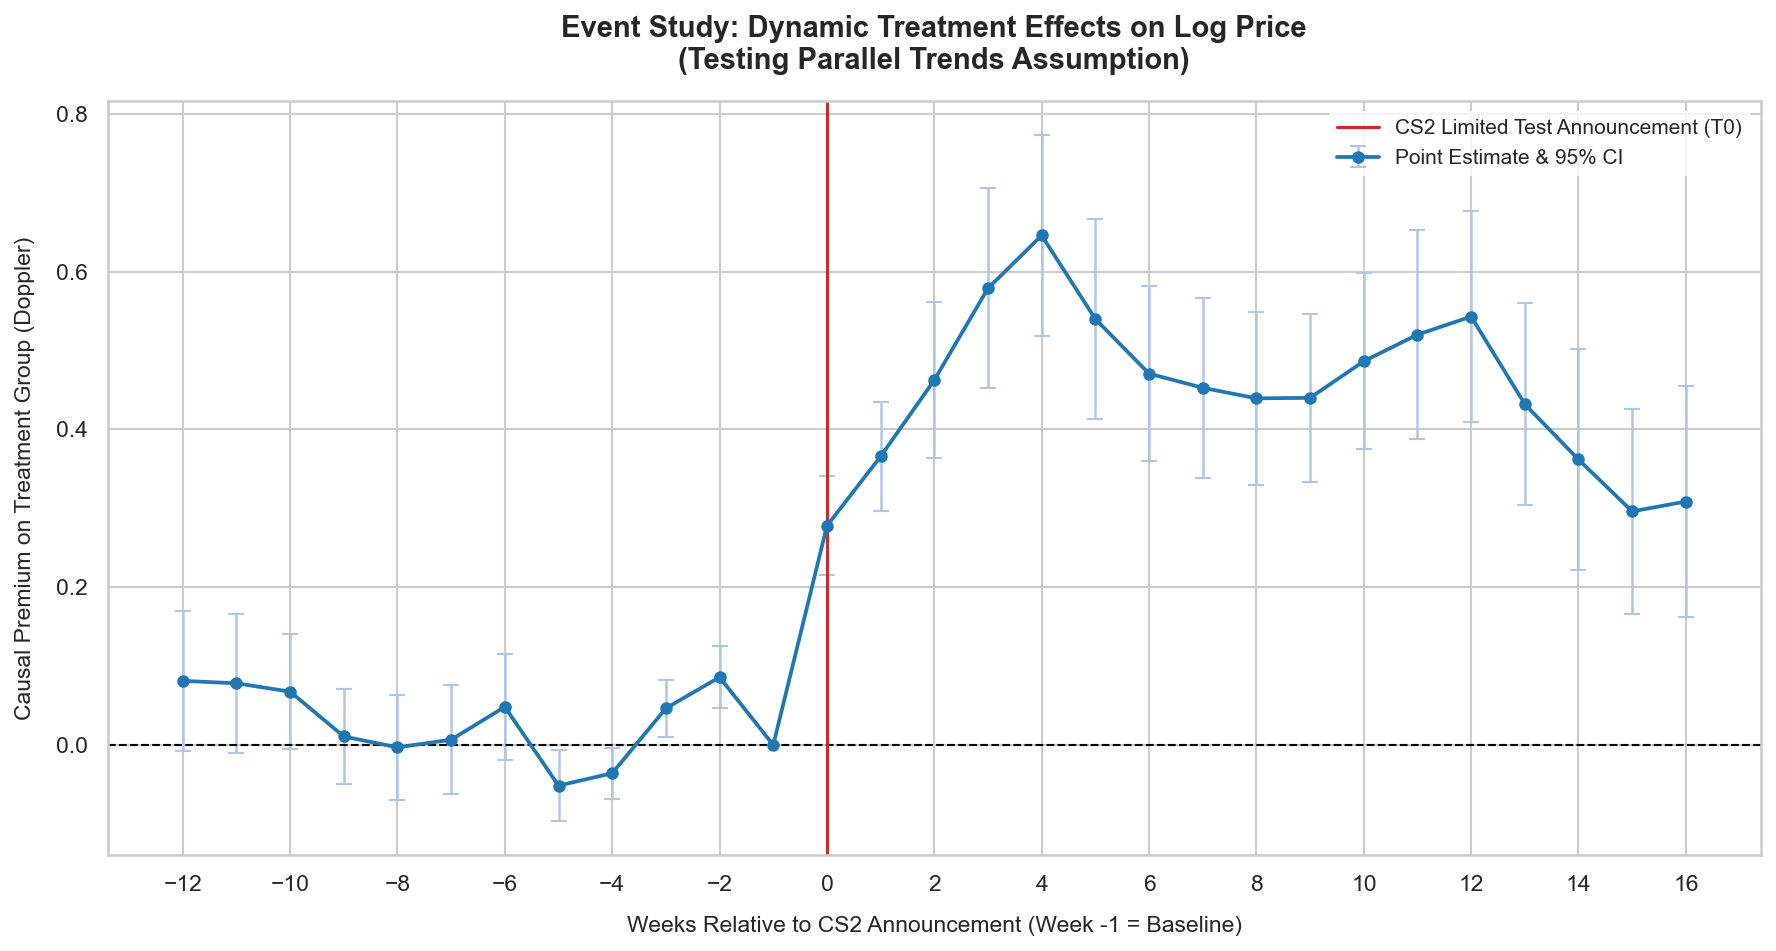


 The ultimate causal inference pipeline is now complete! The parallel trend chart has been successfully saved as 'parallel_trends_verification.png'。


In [13]:
print("Step 5: A parallel trend hypothesis test chart is being drawn...")
weeks_list = []
coefs = []
ci_lower = []
ci_upper = []

for w in unique_weeks:
    if w < 0:
        var_name = f'treat_x_week_pre_{abs(w)}'
    else:
        var_name = f'treat_x_week_post_{w}'
        
    weeks_list.append(w)
    coefs.append(model_event.params[var_name])
    conf = model_event.conf_int().loc[var_name]
    ci_lower.append(conf[0])
    ci_upper.append(conf[1])

weeks_list.append(-1)
coefs.append(0)
ci_lower.append(0)
ci_upper.append(0)

res_df = pd.DataFrame({'week': weeks_list, 'coef': coefs, 'lower': ci_lower, 'upper': ci_upper}).sort_values('week')
res_df['error'] = res_df['coef'] - res_df['lower']

plt.figure(figsize=(12, 6.5), dpi=150)
import seaborn as sns
sns.set_theme(style="whitegrid")

plt.errorbar(res_df['week'], res_df['coef'], yerr=res_df['error'], 
             fmt='-o', color='#1f77b4', linewidth=1.8, markersize=5,
             capsize=4, ecolor='#aec7e8', elinewidth=1.2, label='Point Estimate & 95% CI')

plt.axhline(0, color='black', linestyle='--', linewidth=1.0) 
plt.axvline(0, color='#d62728', linestyle='-', linewidth=1.5, label='CS2 Limited Test Announcement (T0)') 

plt.title('Event Study: Dynamic Treatment Effects on Log Price\n(Testing Parallel Trends Assumption)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Weeks Relative to CS2 Announcement (Week -1 = Baseline)', fontsize=11, labelpad=10)
plt.ylabel('Causal Premium on Treatment Group (Doppler)', fontsize=11, labelpad=10)
plt.xticks(range(-12, 17, 2))
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10)
plt.tight_layout()

plt.savefig('parallel_trends_verification.png', bbox_inches='tight')
plt.show()

print("\n The ultimate causal inference pipeline is now complete! The parallel trend chart has been successfully saved as 'parallel_trends_verification.png'。")

Placebo Test

Step 1: Cleaning data and calculating the true baseline DiD coefficient...
✅ The true causal premium coefficient (True Effect): 0.4109
Step 2: Rapid placebo test (FWL demeaning method acceleration)
 The 50/300 iterations have been completed
 The 100/300 iterations have been completed
 The 150/300 iterations have been completed
 The 200/300 iterations have been completed
 The 250/300 iterations have been completed
 The 300/300 iterations have been completed

✅ Placebo test completed! Empirical P-value: 0.0000
Step 3: Drawing the distribution plot


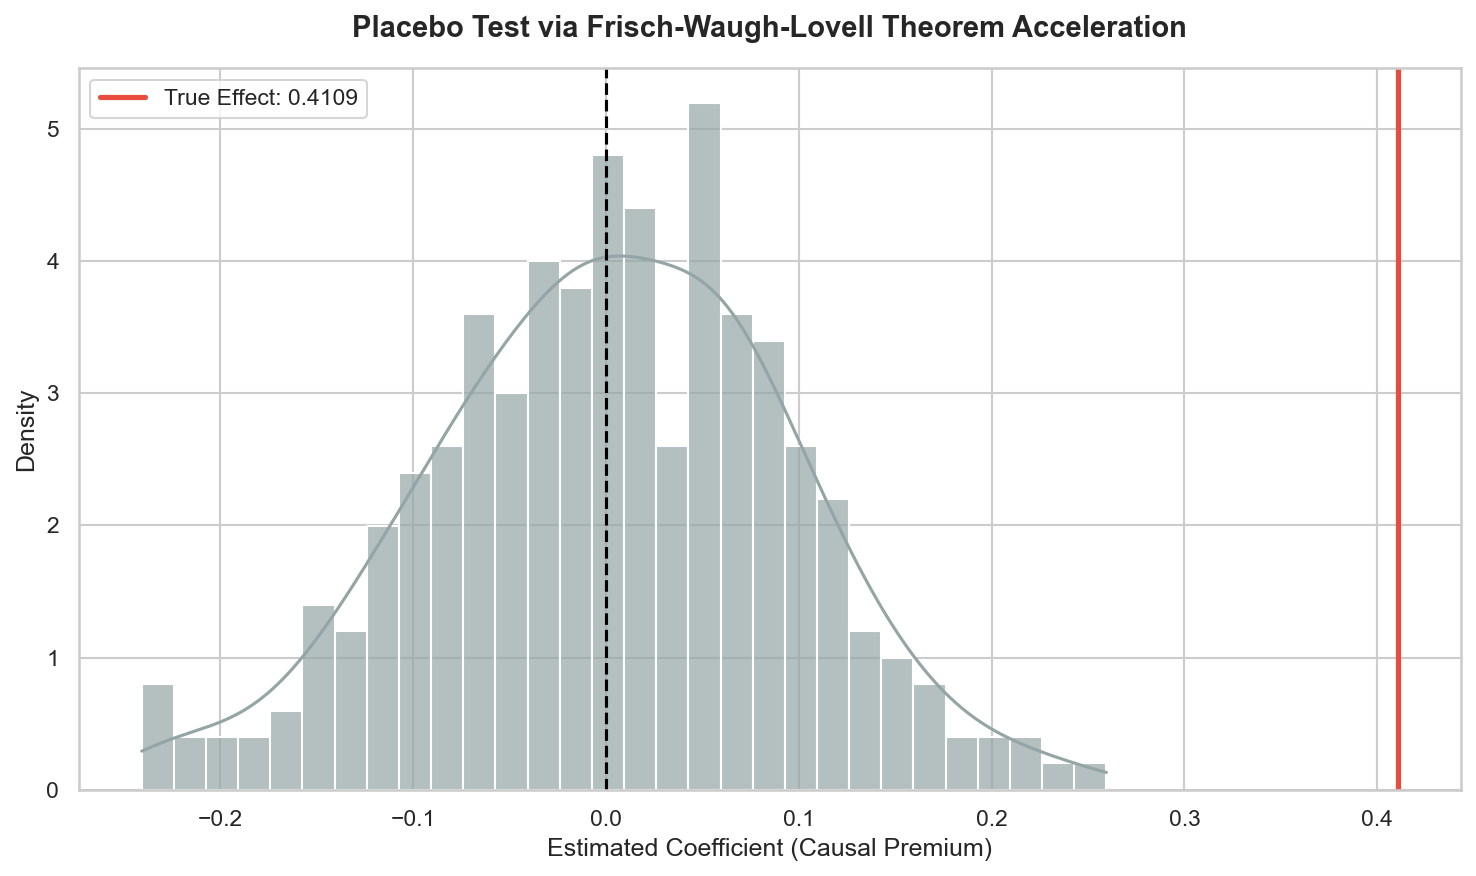

The image has been saved: placebo_test.png


In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1: Cleaning data and calculating the true baseline DiD coefficient...")

df_baseline = df_final.copy()
df_baseline['price'] = pd.to_numeric(df_baseline['price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
df_baseline['btc_price'] = pd.to_numeric(df_baseline['btc_price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
df_baseline['sp500_price'] = pd.to_numeric(df_baseline['sp500_price'].astype(str).str.replace(',', '', regex=False), errors='coerce')
df_baseline = df_baseline.dropna(subset=['price', 'btc_price', 'sp500_price'])

df_baseline['log_price'] = np.log(df_baseline['price'] + 1)
df_baseline['log_btc'] = np.log(df_baseline['btc_price'] + 1)
df_baseline['log_sp500'] = np.log(df_baseline['sp500_price'] + 1)

t0_date = pd.to_datetime('2023-03-22')
df_baseline['is_post'] = (df_baseline['date'] >= t0_date).astype(int)
df_baseline['did_interaction'] = df_baseline['is_treatment'] * df_baseline['is_post']

model_true = smf.ols(
    "log_price ~ did_interaction + log_btc + log_sp500 + C(skin_name) + C(date)",
    data=df_baseline
).fit(cov_type='cluster', cov_kwds={'groups': df_baseline['skin_name']})

true_effect = model_true.params['did_interaction']
print(f"✅ The true causal premium coefficient (True Effect): {true_effect:.4f}")

# =====================================================================
print("Step 2: Rapid placebo test (FWL demeaning method acceleration)")

def demean(x, g1, g2):
    """Double de-mean approximation: Eliminating individual and temporal fixed effects"""
    x = x - x.groupby(g1).transform('mean') 
    x = x - x.groupby(g2).transform('mean') 
    return x

g1 = df_baseline['skin_name']
g2 = df_baseline['date']

y_dm = demean(df_baseline['log_price'], g1, g2).values
x1_dm = demean(df_baseline['log_btc'], g1, g2).values
x2_dm = demean(df_baseline['log_sp500'], g1, g2).values

is_post_raw = df_baseline['is_post'].values
skin_raw = df_baseline['skin_name'].values
unique_skins = np.unique(skin_raw)

n_iterations = 300
n_treatment = 49
placebo_effects = []

for i in range(n_iterations):
    fake_treat = np.random.choice(unique_skins, n_treatment, replace=False)
    fake_treat_flag = np.isin(skin_raw, fake_treat).astype(float)
    
    fake_did = fake_treat_flag * is_post_raw
    
    fake_did_series = pd.Series(fake_did, index=df_baseline.index)
    fake_did_dm = demean(fake_did_series, g1, g2).values

    X = np.column_stack([x1_dm, x2_dm, fake_did_dm])
    X = sm.add_constant(X)

    res = sm.OLS(y_dm, X).fit()
    placebo_effects.append(res.params[-1])
    
    if (i+1) % 50 == 0:
        print(f" The {i+1}/{n_iterations} iterations have been completed")

empirical_p = np.mean(np.abs(placebo_effects) >= np.abs(true_effect))
print(f"\n✅ Placebo test completed! Empirical P-value: {empirical_p:.4f}")

# =====================================================================
print("Step 3: Drawing the distribution plot")

plt.figure(figsize=(10,6), dpi=150)
sns.set_theme(style="whitegrid")

sns.histplot(placebo_effects, bins=30, kde=True, color='#95a5a6', stat='density', alpha=0.7)
plt.axvline(true_effect, color='#e74c3c', linewidth=2.5, label=f'True Effect: {true_effect:.4f}')
plt.axvline(0, color='black', linestyle='--')

plt.title('Placebo Test via Frisch-Waugh-Lovell Theorem Acceleration', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Estimated Coefficient (Causal Premium)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('placebo_test.png', bbox_inches='tight')
plt.show()

print("The image has been saved: placebo_test.png")